In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow as tf
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
x , y = make_moons(100 , noise =.25 , random_state = 2)

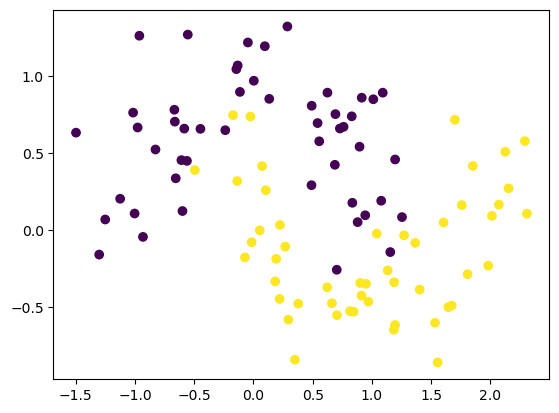

In [3]:
plt.scatter(x[:,0],x[:,1],c=y)

In [4]:
model = Sequential()
model.add(Dense(128 , activation = "relu" , input_dim = 2))
model.add(Dense(128 , activation = "relu" ))
model.add(Dense(1 ,activation = "sigmoid"))

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               384       
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17025 (66.50 KB)
Trainable params: 17025 (66.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
adam = Adam(learning_rate = .01)

In [6]:
model.compile(loss = "binary_crossentropy" , optimizer = adam , metrics = ["accuracy"])

In [7]:
history = model.fit(x,y , epochs = 2000 , validation_split = .2)

Epoch 1/2000


3/3 [==============================] - 1s 114ms/step - loss: 0.6088 - accuracy: 0.6375 - val_loss: 0.3398 - val_accuracy: 0.9000
Epoch 2/2000
3/3 [==============================] - 0s 18ms/step - loss: 0.4131 - accuracy: 0.8500 - val_loss: 0.1863 - val_accuracy: 0.9000
Epoch 3/2000
3/3 [==============================] - 0s 17ms/step - loss: 0.4009 - accuracy: 0.8500 - val_loss: 0.1984 - val_accuracy: 0.9000
Epoch 4/2000
3/3 [==============================] - 0s 18ms/step - loss: 0.3724 - accuracy: 0.8500 - val_loss: 0.2291 - val_accuracy: 0.9000
Epoch 5/2000
3/3 [==============================] - 0s 28ms/step - loss: 0.3554 - accuracy: 0.8375 - val_loss: 0.2738 - val_accuracy: 0.9000
Epoch 6/2000
3/3 [==============================] - 0s 23ms/step - loss: 0.3389 - accuracy: 0.8500 - val_loss: 0.2510 - val_accuracy: 0.9000
Epoch 7/2000
3/3 [==============================] - 0s 19ms/step - loss: 0.3472 - accuracy: 0.8375 - val_loss: 0.2214 - val_accuracy: 0.9000
Epoch 8/20

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


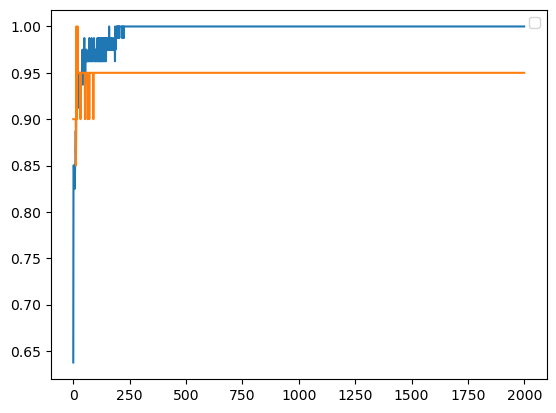

In [8]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend()

9600/9600 [==============================] - 14s 1ms/step


<Axes: >

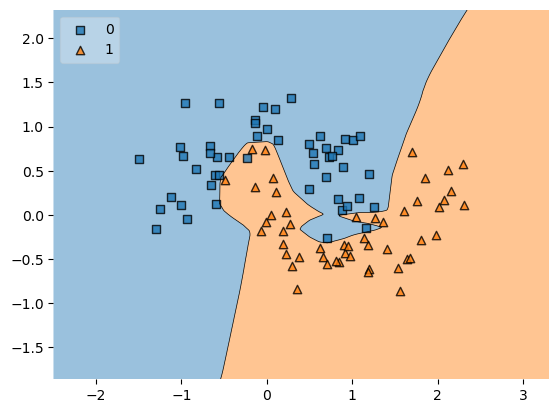

In [9]:
plot_decision_regions(x,y.astype("int") , clf = model , legend = 2)

In [10]:
model2 = Sequential()

model2.add(Dense(128 , input_dim = 2 , activation = "relu" , kernel_regularizer = tf.keras.regularizers.l2(.03)))
model2.add(Dense(128 , activation = "relu" , kernel_regularizer = tf.keras.regularizers.l2(.03)))
model2.add(Dense(1 , activation = "sigmoid"))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               384       
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17025 (66.50 KB)
Trainable params: 17025 (66.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
adam = Adam(learning_rate = .01)
model2.compile(loss = "binary_crossentropy" , optimizer = adam , metrics=["accuracy"])

In [14]:
history1 = model2.fit(x , y , validation_split = .2 , epochs = 2000)

Epoch 1/2000
3/3 [==============================] - 1s 95ms/step - loss: 4.0478 - accuracy: 0.6625 - val_loss: 2.6909 - val_accuracy: 0.9000
Epoch 2/2000
3/3 [==============================] - 0s 16ms/step - loss: 2.3372 - accuracy: 0.7875 - val_loss: 1.5161 - val_accuracy: 0.9000
Epoch 3/2000
3/3 [==============================] - 0s 19ms/step - loss: 1.3499 - accuracy: 0.8250 - val_loss: 0.8555 - val_accuracy: 0.9000
Epoch 4/2000
3/3 [==============================] - 0s 18ms/step - loss: 0.8478 - accuracy: 0.8250 - val_loss: 0.5891 - val_accuracy: 0.9000
Epoch 5/2000
3/3 [==============================] - 0s 17ms/step - loss: 0.6641 - accuracy: 0.8125 - val_loss: 0.5479 - val_accuracy: 0.9000
Epoch 6/2000
3/3 [==============================] - 0s 17ms/step - loss: 0.6325 - accuracy: 0.8250 - val_loss: 0.5501 - val_accuracy: 0.9000
Epoch 7/2000
3/3 [==============================] - 0s 19ms/step - loss: 0.6442 - accuracy: 0.8125 - val_loss: 0.5432 - val_accuracy: 0.9000
Epoch 8/2000


9600/9600 [==============================] - 13s 1ms/step


<Axes: >

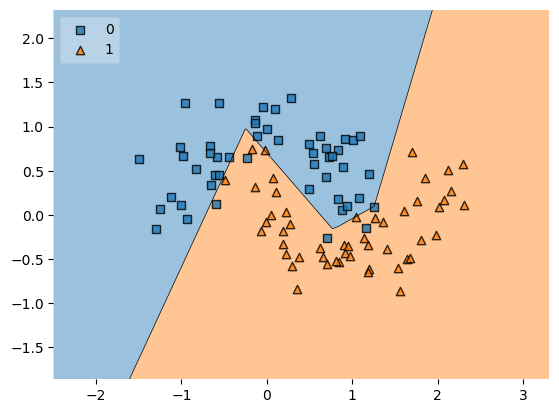

In [15]:
plot_decision_regions(x,y.astype("int") , clf = model2 , legend= 2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


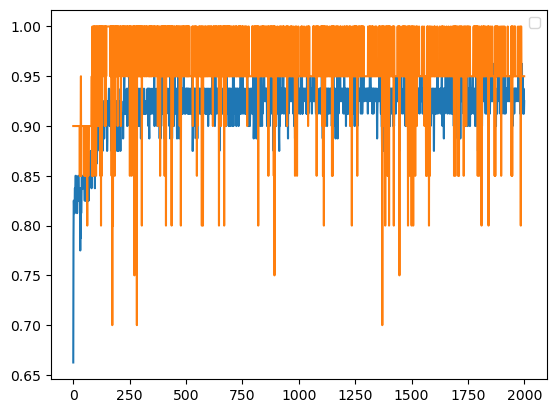

In [16]:
plt.plot(history1.history["accuracy"])
plt.plot(history1.history["val_accuracy"])
plt.legend()